Logistic Regression is a classification algorithm, not a regression one (despite the name). It’s used when the output (target) is categorical, typically:
1.Binary (e.g., Yes/No, 0/1, Spam/Not Spam)
2.Multiclass (with extensions like softmax)
Ex. - Predicting whether a student will pass (1) or fail (0) based on hours studied.

Workflow :
1.Use Linear Regression to get a value (called the logit).
2.Pass it through the Sigmoid function to squash it between 0 and 1.
3.Interpret that output as a probability of belonging to class 1.
4.Use a threshold (e.g., 0.5) to classify the output:
If probability ≥ 0.5 → consider it 1 Else → consider it 0

Formulas :
logit(z) = θ0 + θ1X
g(z) = 1/(1+e^-z)
If z = 0 then g(z) = 0.5, if z > 0 then g(z) > 0.5 and if z < 0 then g(z) < 0.5 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris

In [2]:
data = load_iris()
df = pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df['species'] = np.array(data.target_names)[data.target]  #adds a new column called 'species' to DataFrame, mapping each number to its corresponding flower name. 
# other method : df['species'] = pd.Categorical.from_codes(data.target, data.target_names)
df['species'].unique()   #This shows all the unique species names present in the DataFrame.

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [6]:
df.shape

(150, 5)

In [7]:
df = df[df['species']!='setosa']        # Remove setosa to get binary number of output

In [8]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [10]:
df.shape

(100, 5)

In [9]:
df['species'] = df['species'].map({'versicolor':0,'virginica':1})

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0


In [12]:
# split dataset into independent and dependent features 
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [14]:
regressor = LogisticRegression()

In [ ]:
parameter = {'penalty':['l1','l2','elasticnet'],'C':[0.1,0.001,0.4,0.5,1,2,3,4,5,6,10,20,30,40,50,60],'max_iter':[100,200,300],'solver': ['saga'],'l1_ratio': [0.5]}
# c is the inverse of regularization strengh
# max_iter is how many iterations need to find best model

In [16]:
lcv = GridSearchCV(regressor,param_grid=parameter,scoring='accuracy',cv=5)

In [17]:
lcv.fit(x_train,y_train)

d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\jbook\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 0.001, ...], 'l1_ratio': [0.5], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [18]:
lcv.best_params_

{'C': 0.4, 'l1_ratio': 0.5, 'max_iter': 300, 'penalty': 'l2', 'solver': 'saga'}

In [19]:
print(lcv.best_score_)

1.0


In [20]:
y_pred = lcv.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score,classification_report,precision_score,log_loss

In [41]:
score = accuracy_score(y_test,y_pred)
score

0.92

In [23]:
precision_score(y_test,y_pred)

0.8461538461538461

In [39]:
log_loss(y_test, lcv.predict_proba(x_test))

0.3557795706706247

In [40]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.85      0.92        13

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25



In [ ]:
print(np.bincount(y))

[50 50]


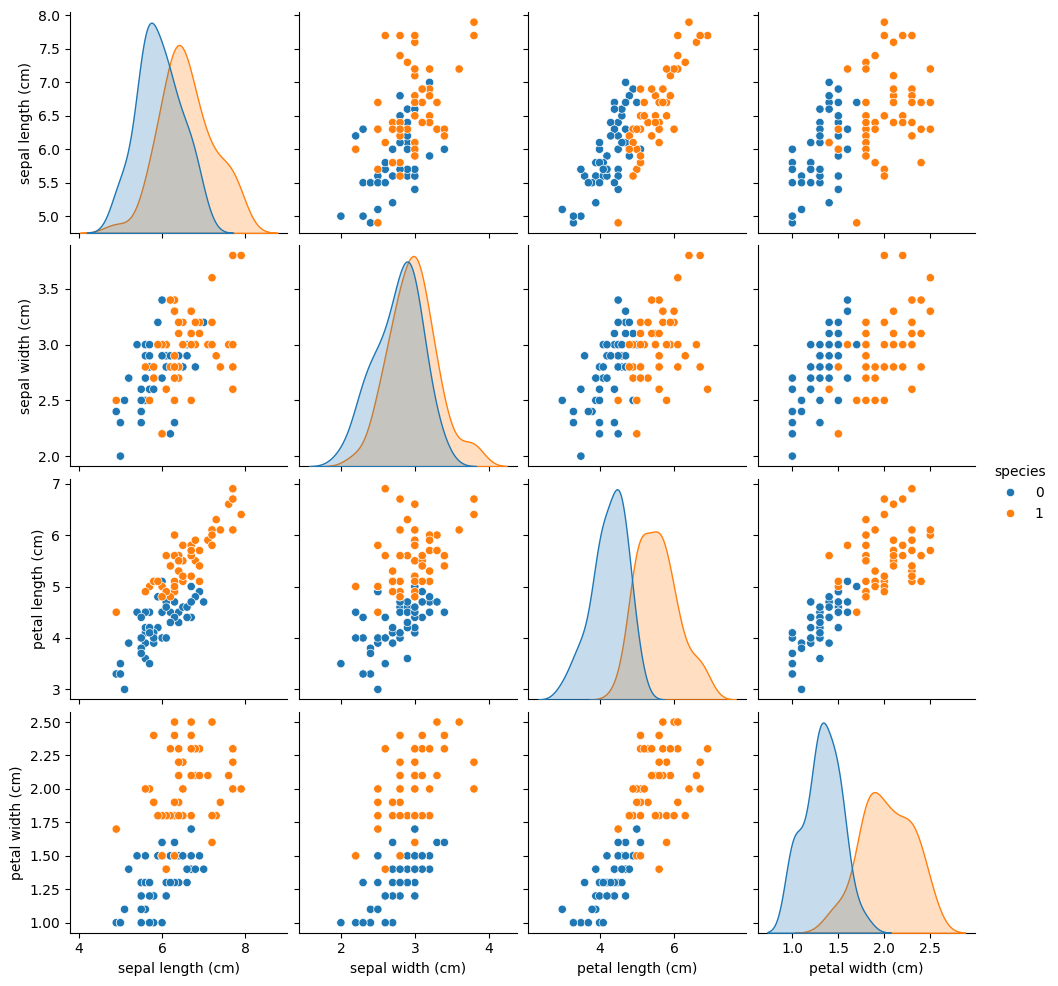

In [ ]:
# EDA
sns.pairplot(df,hue='species')